# BTK Datathon 2026 — Data Understanding & Baseline Notebook

This notebook is designed as the **first clean notebook** for the project.

Main goal:

1. Understand what the dataset contains
2. Check target distribution and missing values
3. Separate numeric, categorical, and text features
4. Build a safe baseline model
5. Create a valid submission file

This is not the final advanced model notebook.  
The purpose is to make the project explainable, reproducible, and safe before moving into heavy modeling.

## 1. Imports and Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import FunctionTransformer
RANDOM_STATE = 42
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

## 2. Load Data

Expected local structure:

```text
data/
├── train.csv
├── test_x.csv
└── sample_submission.csv
```

In [2]:
DATA_DIR = "../data"   # If your notebook is inside notebooks/
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test_x.csv")
SAMPLE_PATH = os.path.join(DATA_DIR, "sample_submission.csv")

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

display(train.head())
display(test.head())
display(sample_submission.head())

Train shape: (10000, 47)
Test shape: (10000, 46)
Sample submission shape: (2, 2)


,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,target_role,coding_score,problem_solving_score,data_structures_score,sql_score,machine_learning_score,backend_score,frontend_score,cloud_score,devops_score,project_quality_score,real_client_project_count,internship_count,internship_duration_months,freelance_project_count,hackathon_count,hackathon_awards,portfolio_score,github_repo_count,github_avg_stars,open_source_contribution_count,linkedin_profile_score,cv_quality_score,technical_interview_score,hr_interview_score,communication_score,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,career_success_score,mentor_feedback_text
0,STU_000001,2021,21,2021,Computer Engineering,Tier 4,3.17,62.54,77.31,0,DevOps Engineer,73.28,71.11,52.91,84.980000,81.77,62.710000,71.570000,63.041897,69.952625,81.90,0,3,11.0,0,0,0,65.54,18,1.85,10.0,86.58,42.06,40.57,50.29,79.83,44.14,62.70,58.84,3,1,24,0,photography,LinkedIn,86.78,"Proje kalitesi ve makine öğrenimi konusundaki uzmanlığı dikkat çekici. SQL becerisi ile birlikte, DevOps alanında gelişim gösterse de, veri yapıları ve teknik görüşme sonuçlarında daha fazla çalış..."
1,STU_000002,2024,20,2024,Computer Engineering,Tier 4,3.24,75.10,87.13,3,Backend Developer,63.12,78.90,61.81,37.450740,65.54,69.944694,60.830000,64.510000,57.940000,24.68,0,0,NaN,1,1,0,54.48,7,1.22,1.0,33.34,65.39,82.99,67.43,43.60,22.05,42.32,40.54,2,0,46,5,reading,YouTube,46.16,"Kodlama ve problem çözme becerileri gelişmekte olan bir öğrenci için umut verici, ancak projesinin kalitesi ve iletişim becerileri üzerinde çalışması gerekiyor. Backend geliştirme alanında daha fa..."
2,STU_000003,2024,28,2024,Electrical Electronics Engineering,Tier 4,3.00,68.53,95.64,1,Frontend Developer,100.00,86.44,83.62,85.440000,87.18,80.580000,96.433149,62.220000,81.750000,78.92,2,0,0.0,2,0,0,75.10,4,12.12,2.0,61.37,52.25,43.06,20.19,48.62,65.64,47.27,82.56,1,2,46,5,cinema,Reddit,84.08,"İleri düzey frontend geliştirme becerileri ile proje bazında önemli deneyimler edinmiş. Ancak, liderlik ve iletişim alanında daha fazla çalışması, kariyer hedeflerini destekleyebilir. Teknik bilgi..."
3,STU_000004,2019,22,2018,Computer Engineering,Tier 1,2.82,54.85,77.80,2,Backend Developer,99.08,72.15,77.15,89.214871,69.49,85.751415,72.860000,73.680000,54.080000,54.93,0,1,9.0,0,1,0,82.40,4,2.96,3.0,45.15,24.12,32.06,28.00,59.84,3.89,78.69,85.05,2,4,49,7,running,Reddit,89.97,"Güçlü bir kodlama yeteneği ve backend geliştirme konusundaki deneyimi ile dikkat çekiyor. Ancak, ekip çalışması ve iletişim konularında daha fazla gelişme kaydetmesi, kariyerinde güçlü bir temel o..."
4,STU_000005,2026,22,2026,Computer Engineering,Tier 3,2.28,72.25,71.97,1,Product Analyst,92.65,91.15,84.51,70.700000,74.11,80.620000,86.830000,80.340000,87.560000,72.85,2,0,NaN,2,0,0,48.02,14,0.97,12.0,74.86,74.83,71.82,65.14,63.30,52.86,27.22,84.29,1,0,119,13,football,X,92.46,"Ürün analizi alanına olan tutkusu ve makine öğrenimindeki yetkinliği ile dikkat çekiyor. Ancak, portföyünde daha fazla derinlik sağlamak ve işbirliği becerilerini geliştirmek, kariyer hedeflerine ..."


,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,target_role,coding_score,problem_solving_score,data_structures_score,sql_score,machine_learning_score,backend_score,frontend_score,cloud_score,devops_score,project_quality_score,real_client_project_count,internship_count,internship_duration_months,freelance_project_count,hackathon_count,hackathon_awards,portfolio_score,github_repo_count,github_avg_stars,open_source_contribution_count,linkedin_profile_score,cv_quality_score,technical_interview_score,hr_interview_score,communication_score,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,mentor_feedback_text
0,STU_010001,2025,23,2025,Computer Engineering,Tier 4,2.59,45.27,79.11,2,Frontend Developer,42.60,61.53,61.17,34.780000,39.570000,59.61,39.143557,43.540000,52.800000,40.83,1,2,14.0,1,0,0,92.14,8,NaN,NaN,15.41,52.16,62.90,41.79,51.08,90.02,81.33,30.54,6,2,46,6,gaming,YouTube,"Öğrencinin proje çalışmasında dikkat çekici bir özveri sergilediğini gözlemledim. Frontend alanında daha fazla pratik yapması gerektiği aşikar, ancak takım çalışması konusundaki yetenekleri ile gü..."
1,STU_010002,2023,23,2022,Electrical Electronics Engineering,Tier 3,3.12,66.30,70.58,1,DevOps Engineer,71.63,95.42,81.59,78.360000,79.410000,74.65,60.360000,84.594122,66.284347,31.24,1,1,5.0,1,2,0,40.16,7,3.64,0.0,43.73,67.56,43.15,83.47,38.26,82.78,82.78,42.37,1,0,4,0,football,TikTok,"Bu öğrenci, problem çözme ve veri yapıları konusundaki olağanüstü yetenekleri ile dikkat çekiyor. DevOps alanındaki bilgisi gelişmeye açık olsa da, iletişim ve takım çalışmasındaki güçlü yönleriyl..."
2,STU_010003,2025,20,2025,Computer Engineering,Tier 3,3.48,75.45,67.93,0,Data Scientist,66.04,62.71,67.52,89.176084,58.108534,78.01,69.610000,66.840000,54.060000,26.53,1,1,2.0,3,0,0,59.12,8,NaN,NaN,14.96,68.73,71.74,64.96,88.49,51.79,63.30,66.01,4,1,66,3,cinema,Instagram,"Öğrencinin veri bilimi konusundaki ilgisi ve genel teknik becerileri etkileyici bir seviyeye ulaşmış durumda. SQL ve iletişim becerilerindeki güçlü yönleri, onu takım projelerinde önemli bir katkı..."
3,STU_010004,2020,26,2019,Software Engineering,Tier 2,2.92,45.58,83.95,0,Data Analyst,91.53,67.55,75.47,66.948792,62.822398,66.92,94.010000,64.990000,61.700000,82.96,1,0,0.0,0,1,0,73.90,9,3.18,3.0,NaN,52.79,84.60,79.40,76.32,90.89,46.64,82.60,3,2,42,2,chess,LinkedIn,"Son derece etkileyici bir başarıya imza atan bu öğrenci, yazılım mühendisliği alanındaki derin bilgisi ile dikkat çekiyor. Frontend geliştirme konusundaki ustalığı ve proje kalitesiyle, kariyerind..."
4,STU_010005,2024,21,2024,Computer Engineering,Tier 3,2.85,63.08,84.18,1,Software Developer,70.82,70.65,65.16,62.290000,70.590000,54.44,80.420000,41.970000,63.230000,79.70,2,1,6.0,1,1,0,79.54,6,2.04,6.0,58.00,33.37,33.40,77.29,48.09,42.78,43.30,39.65,3,1,25,0,reading,TikTok,"Öğrencinin yazılım geliştirme alanındaki çalışmaları ve proje kalitesi oldukça etkileyici. Ancak, teknik mülakat becerilerinin ve iletişim yeteneklerinin daha fazla geliştirilmesi gerektiği görülü..."


,student_id,career_success_score
0,STU_010001,12.94
1,STU_010002,123.94


## 3. Basic Dataset Checks

In [3]:
print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

target_col = "career_success_score"
id_col = "student_id"
text_col = "mentor_feedback_text"

print("\nTarget exists in train:", target_col in train.columns)
print("Target exists in test:", target_col in test.columns)

print("\nDuplicated student IDs in train:", train[id_col].duplicated().sum())
print("Duplicated student IDs in test:", test[id_col].duplicated().sum())

print("\nTrain dtypes:")
display(train.dtypes.value_counts())

Train columns:
['student_id', 'application_year', 'age', 'graduation_year', 'department', 'university_tier', 'cgpa', 'english_exam_score', 'attendance_rate', 'failed_courses_count', 'target_role', 'coding_score', 'problem_solving_score', 'data_structures_score', 'sql_score', 'machine_learning_score', 'backend_score', 'frontend_score', 'cloud_score', 'devops_score', 'project_quality_score', 'real_client_project_count', 'internship_count', 'internship_duration_months', 'freelance_project_count', 'hackathon_count', 'hackathon_awards', 'portfolio_score', 'github_repo_count', 'github_avg_stars', 'open_source_contribution_count', 'linkedin_profile_score', 'cv_quality_score', 'technical_interview_score', 'hr_interview_score', 'communication_score', 'teamwork_score', 'leadership_score', 'presentation_score', 'certification_count', 'bootcamp_count', 'applications_sent', 'interviews_attended', 'hobby', 'preferred_social_media_platform', 'career_success_score', 'mentor_feedback_text']

Test colum

float64    26
int64      14
object      7
Name: count, dtype: int64

## 4. Target Analysis

The target is a continuous score between 0 and 100.  
Since the competition metric is MSE, large mistakes are punished heavily.

count    10000.000000
mean        76.942507
std         15.186669
min          0.000000
25%         66.937500
50%         77.810000
75%         88.472500
max        100.000000
Name: career_success_score, dtype: float64

Target min: 0.0
Target max: 100.0


<Axes: >

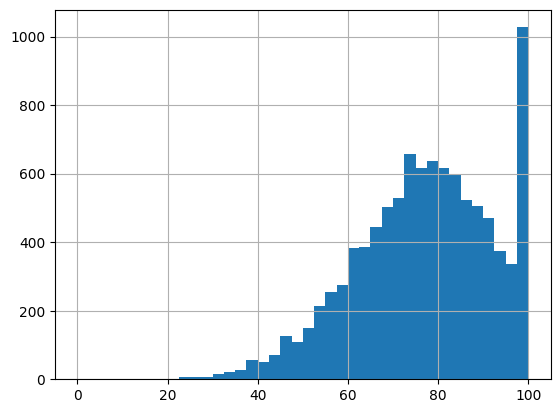

In [4]:
display(train[target_col].describe())

print("Target min:", train[target_col].min())
print("Target max:", train[target_col].max())

train[target_col].hist(bins=40)

## 5. Missing Value Analysis

In [5]:
missing_train = train.isna().sum().sort_values(ascending=False)
missing_train = missing_train[missing_train > 0]

missing_test = test.isna().sum().sort_values(ascending=False)
missing_test = missing_test[missing_test > 0]

print("Missing values in train:")
display(missing_train.to_frame("missing_count"))

print("Missing values in test:")
display(missing_test.to_frame("missing_count"))

Missing values in train:


,missing_count
internship_duration_months,1657
english_exam_score,953
open_source_contribution_count,910
github_avg_stars,910
hr_interview_score,780
linkedin_profile_score,668
portfolio_score,364


Missing values in test:


,missing_count
internship_duration_months,1586
english_exam_score,944
github_avg_stars,895
open_source_contribution_count,895
hr_interview_score,759
linkedin_profile_score,680
portfolio_score,382


## 6. Feature Groups

We separate the dataset into:

- ID column: not used for modeling
- Target column: prediction target
- Text column: handled with TF-IDF
- Numeric columns
- Categorical columns

In [6]:
feature_cols = [c for c in train.columns if c not in [target_col]]
X = train[feature_cols].copy()
y = train[target_col].copy()
X_test = test.copy()

# Keep test IDs for submission
test_ids = X_test[id_col].copy()

# Drop ID from features
X = X.drop(columns=[id_col])
X_test_features = X_test.drop(columns=[id_col])

numeric_cols = X.drop(columns=[text_col]).select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.drop(columns=[text_col]).select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nText column:", text_col)

Numeric columns: 39
['application_year', 'age', 'graduation_year', 'cgpa', 'english_exam_score', 'attendance_rate', 'failed_courses_count', 'coding_score', 'problem_solving_score', 'data_structures_score', 'sql_score', 'machine_learning_score', 'backend_score', 'frontend_score', 'cloud_score', 'devops_score', 'project_quality_score', 'real_client_project_count', 'internship_count', 'internship_duration_months', 'freelance_project_count', 'hackathon_count', 'hackathon_awards', 'portfolio_score', 'github_repo_count', 'github_avg_stars', 'open_source_contribution_count', 'linkedin_profile_score', 'cv_quality_score', 'technical_interview_score', 'hr_interview_score', 'communication_score', 'teamwork_score', 'leadership_score', 'presentation_score', 'certification_count', 'bootcamp_count', 'applications_sent', 'interviews_attended']

Categorical columns: 5
['department', 'university_tier', 'target_role', 'hobby', 'preferred_social_media_platform']

Text column: mentor_feedback_text


## 7. Quick Correlation Check for Numeric Features

This helps us understand which structured variables are most related to the target.

In [7]:
corr_df = train[numeric_cols + [target_col]].corr(numeric_only=True)[target_col].sort_values(ascending=False)
display(corr_df.to_frame("correlation_with_target").head(20))
display(corr_df.to_frame("correlation_with_target").tail(20))

,correlation_with_target
career_success_score,1.000000
project_quality_score,0.541063
technical_interview_score,0.340448
problem_solving_score,0.289990
cloud_score,0.276863
coding_score,0.274396
devops_score,0.272033
portfolio_score,0.270772
backend_score,0.266532
real_client_project_count,0.258805


,correlation_with_target
presentation_score,0.097600
teamwork_score,0.071102
cv_quality_score,0.070092
internship_duration_months,0.054276
hackathon_awards,0.048572
interviews_attended,0.039336
linkedin_profile_score,0.038942
internship_count,0.035379
leadership_score,0.032522
hackathon_count,0.031047


## 8. Text Feature Quick Look

The mentor feedback text should not be ignored because the competition statement explicitly highlights it.

In [8]:
print("Example mentor feedback texts:")
display(train[[text_col, target_col]].sample(10, random_state=RANDOM_STATE))

Example mentor feedback texts:


,mentor_feedback_text,career_success_score
6252,"Takım çalışması ve liderlik becerilerin, projelerdeki katılımınla pekişiyor; ancak teknik yeteneklerini geliştirmek için daha fazla uygulamalı deneyim kazanmalısın. SQL ve makine öğrenimi alanında...",67.69
4684,"Veri bilimi alanına olan ilginiz ve proje deneyimleriniz, teknik bilgi birikiminizle birleştiğinde güçlü bir profil oluşturuyor. Ancak, temel programlama becerilerinizi güçlendirmeniz ve daha etki...",85.45
1731,Gerçekleştirdiğiniz projelere olan yaklaşımınız önemli bir öğrenme süreci sağlıyor; ancak teknik becerilerinizin geliştirilmesi gerektiği açık. Özellikle kodlama ve sorun çözme alanlarında daha fa...,45.02
4742,"Bu öğrencinin problem çözme yeteneği çok yüksek, ancak kodlama ve veri yapıları gibi temel konularda daha fazla derinleşmesi gerekebilir. Açık kaynak katkıları ve GitHub projeleri ile deneyim kaza...",67.09
4521,"Takım çalışmasına yatkınlığıyla öne çıkan bu öğrenci, gerçek müşteri projelerinde edindiği deneyimlerle pratik becerilerini geliştirdi. Ancak, kodlama ve problem çözme alanlarında biraz daha derin...",93.72
6340,"Proje çalışmasında gösterdiği azim ve çaba özellikle backend geliştirme konusundaki yeteneklerini sergiliyor. GitHub üzerindeki projeleri ve kazanılan tecrübeler, güçlü bir yazılım geliştirme teme...",71.38
576,"Backend geliştirme alanında kendisini geliştiren öğrencim, özellikle problem çözme becerileri ile dikkat çekiyor. Ancak, iletişim ve takım çalışması konularında daha fazla gelişim göstererek kariy...",64.66
5202,"Proje yönetimi ve veri yapıları konusundaki güçlü yönleri ile dikkat çeken bu öğrenci, backend geliştirme alanında büyük bir potansiyele sahip. Ancak, takım çalışması ve iletişim becerilerinde dah...",90.77
6363,"Bulut mühendisliği hedefleyen öğrencim, projelerinde yenilikçi yaklaşımlar sergiliyor ama proje kalitesi konusunda daha fazla deneyim kazanması gerekiyor. Ek olarak, liderlik yeteneklerinin güçlü ...",72.82
439,"Gelişen portföyünle dikkat çeken yazılım bilgilerini bir araya getirerek AI alanında sağlam bir zemin oluşturuyorsun. Fakat toplantı ve iletişim becerilerini geliştirmek, takım içinde daha etkili ...",58.89


## 9. Baseline 1 — Mean Prediction

This is the simplest possible baseline. Any real model should beat this.

In [9]:
mean_pred = np.full(shape=len(y), fill_value=y.mean())
baseline_mse = mean_squared_error(y, mean_pred)
baseline_rmse = baseline_mse ** 0.5

print("Mean baseline MSE:", baseline_mse)
print("Mean baseline RMSE:", baseline_rmse)

Mean baseline MSE: 230.61185168495098
Mean baseline RMSE: 15.18590964298652


## 10. Baseline 2 — Structured + Text Pipeline with Ridge

This baseline combines:

- Numeric features with median imputation and scaling
- Categorical features with most-frequent imputation and one-hot encoding
- Mentor feedback text with TF-IDF
- Ridge regression

Ridge is a good sanity-check model because it is stable and fast.

In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

text_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="")),
    ("to_1d", FunctionTransformer(lambda x: x.ravel(), validate=False)),
    ("tfidf", TfidfVectorizer(
        max_features=3000,
        ngram_range=(1, 2),
        min_df=2
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
        ("text", text_transformer, [text_col])
    ],
    remainder="drop"
)

ridge_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=10.0, random_state=RANDOM_STATE))
])

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

neg_mse_scores = cross_val_score(
    ridge_model,
    X,
    y,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

mse_scores = -neg_mse_scores

print("Ridge + TF-IDF CV MSE scores:", mse_scores)
print("Mean CV MSE:", mse_scores.mean())
print("Mean CV RMSE:", np.sqrt(mse_scores.mean()))
print("Std CV MSE:", mse_scores.std())

Ridge + TF-IDF CV MSE scores: [89.73934788 91.29423329 84.00234393 83.54273735 90.27388865]
Mean CV MSE: 87.7705102199182
Mean CV RMSE: 9.36859168818442
Std CV MSE: 3.305540504980906


## 11. Train Baseline Model on Full Training Data

In [11]:
ridge_model.fit(X, y)
test_predictions = ridge_model.predict(X_test_features)

# The target is described as a 0-100 score, so we clip predictions safely.
test_predictions = np.clip(test_predictions, 0, 100)

print("Prediction min:", test_predictions.min())
print("Prediction max:", test_predictions.max())
print("Prediction mean:", test_predictions.mean())

Prediction min: 34.58312019394105
Prediction max: 100.0
Prediction mean: 76.03847922402873


## 12. Create Submission File

In [12]:
submission = pd.DataFrame({
    id_col: test_ids,
    target_col: test_predictions
})

display(submission.head())
display(submission[target_col].describe())

os.makedirs("../submissions", exist_ok=True)
submission_path = "../submissions/submission_baseline_ridge_tfidf.csv"
submission.to_csv(submission_path, index=False)

print("Saved submission to:", submission_path)

,student_id,career_success_score
0,STU_010001,62.126529
1,STU_010002,71.436399
2,STU_010003,72.145599
3,STU_010004,100.000000
4,STU_010005,69.297468


count    10000.000000
mean        76.038479
std         11.766936
min         34.583120
25%         68.107298
50%         75.964276
75%         84.067379
max        100.000000
Name: career_success_score, dtype: float64

Saved submission to: ../submissions/submission_baseline_ridge_tfidf.csv


## 13. Next Experiments

After this baseline works, stronger experiments can include:

1. CatBoost on structured features
2. LightGBM / XGBoost with engineered features
3. Better text features from mentor feedback
4. SentenceTransformer embeddings
5. Out-of-fold stacking
6. Weighted blending of stable models
7. Error analysis by department, target role, and university tier

Important: do not jump directly into complex models before this notebook runs from top to bottom.

## Baseline Result Summary

The initial mean baseline produced an MSE of approximately 230.61 and an RMSE of 15.19.  
After combining structured tabular features with TF-IDF features extracted from `mentor_feedback_text`, the Ridge baseline achieved a 5-fold cross-validation MSE of approximately 87.77 and an RMSE of 9.37.

This shows that both structured student profile variables and mentor feedback text contain useful predictive signals for estimating `career_success_score`.

The generated submission was saved as:

`../submissions/submission_baseline_ridge_tfidf.csv`